In [7]:
#  Install and import
!pip install yfinance fredapi statsmodels pandas matplotlib seaborn scikit-learn

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fredapi import Fred
import warnings
warnings.filterwarnings('ignore')

#Variables of Choice

 Apple Inc. (AAPL) is selected as it is one of the largest companies in the S&P 500, because it has high liquidity, broad market influence, and its performance is sensitive to macroeconomic conditions.

Three US Economic Factors:
Consumer Price Index (CPI) — Inflation: Inflation directly affects consumer purchasing power. When inflation rises, consumers may cut back on discretionary spending (like iPhones, MacBooks), potentially hurting Apple's revenue and stock price.
Unemployment Rate: The unemployment rate reflects the health of the labor market and consumer confidence. Higher unemployment means fewer people with disposable income to buy Apple products.
Federal Funds Rate (Interest Rate): The Fed Funds Rate is the primary tool the Federal Reserve uses to manage the economy. Higher interest rates increase borrowing costs for companies and consumers. Tech stocks are especially sensitive to rate changes because much of their valuation is based on future growth.

Data Sources:

AAPL Stock Price: Yahoo Finance (monthly adjusted close prices)
CPI (Inflation): U.S. Bureau of Labor Statistics (BLS) via FRED (Federal Reserve Economic Data)
Unemployment Rate: U.S. Bureau of Labor Statistics via FRED
Federal Funds Rate: Board of Governors of the Federal Reserve via FRED

In [17]:
# Download data
FRED_API_KEY = '3f2c8b63b0964b79fff830089dc302dd'
fred = Fred(api_key=FRED_API_KEY)

# Date range
start = '2015-01-01'
end = '2024-12-31'

# 1. AAPL stock price (monthly)
aapl = yf.download('AAPL', start=start, end=end, interval='1mo')
# 1. AAPL stock price (monthly)
aapl = yf.download('AAPL', start=start, end=end, interval='1mo')
aapl_monthly = aapl[['Close']].rename(columns={'Close': 'AAPL_Price'})
aapl_monthly.index = aapl_monthly.index.to_period('M')
print(aapl.columns.tolist())

# 2. CPI (CPIAUCSL - Consumer Price Index for All Urban Consumers)
cpi = fred.get_series('CPIAUCSL', observation_start=start, observation_end=end)
cpi = cpi.to_frame(name='CPI')
cpi.index = pd.to_datetime(cpi.index).to_period('M')

# 3. Unemployment Rate (UNRATE)
unemployment = fred.get_series('UNRATE', observation_start=start, observation_end=end)
unemployment = unemployment.to_frame(name='Unemployment_Rate')
unemployment.index = pd.to_datetime(unemployment.index).to_period('M')

# 4. Federal Funds Rate (FEDFUNDS)
fed_rate = fred.get_series('FEDFUNDS', observation_start=start, observation_end=end)
fed_rate = fed_rate.to_frame(name='Fed_Funds_Rate')
fed_rate.index = pd.to_datetime(fed_rate.index).to_period('M')

# Merge all into one DataFrame
df = aapl_monthly.join([cpi, unemployment, fed_rate], how='inner')
df = df.dropna()
print(f"Dataset shape: {df.shape}")
df.head(10)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


[('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL')]
Dataset shape: (120, 4)


,"(AAPL_Price, AAPL)",CPI,Unemployment_Rate,Fed_Funds_Rate
2015-01,25.949114,234.747,5.7,0.11
2015-02,28.451895,235.342,5.5,0.11
2015-03,27.668072,235.976,5.4,0.11
2015-04,27.828169,236.222,5.4,0.12
2015-05,28.968874,237.001,5.6,0.12
2015-06,28.006924,237.657,5.3,0.13
2015-07,27.084757,238.034,5.2,0.13
2015-08,25.177885,238.033,5.1,0.14
2015-09,24.740074,237.498,5.0,0.14
2015-10,26.803614,237.733,5.0,0.12


In [18]:
#check what's in the dataframe
print(df.columns.tolist())
print(df.dtypes)
print(df.head())

[('AAPL_Price', 'AAPL'), 'CPI', 'Unemployment_Rate', 'Fed_Funds_Rate']
(AAPL_Price, AAPL)    float64
CPI                   float64
Unemployment_Rate     float64
Fed_Funds_Rate        float64
dtype: object
         (AAPL_Price, AAPL)      CPI  Unemployment_Rate  Fed_Funds_Rate
2015-01           25.949114  234.747                5.7            0.11
2015-02           28.451895  235.342                5.5            0.11
2015-03           27.668072  235.976                5.4            0.11
2015-04           27.828169  236.222                5.4            0.12
2015-05           28.968874  237.001                5.6            0.12


In [19]:
# 1. AAPL stock price (monthly)
aapl = yf.download('AAPL', start=start, end=end, interval='1mo')
aapl.columns = aapl.columns.get_level_values(0)  # Flatten multi-level columns
aapl_monthly = aapl[['Close']].rename(columns={'Close': 'AAPL_Price'})
aapl_monthly.index = aapl_monthly.index.to_period('M')

[*********************100%***********************]  1 of 1 completed


In [21]:
#rename the tuple column
print(df.columns.tolist())
df.columns = [col if isinstance(col, str) else col[0] for col in df.columns]
print(df.columns.tolist())
df.head()

[('AAPL_Price', 'AAPL'), 'CPI', 'Unemployment_Rate', 'Fed_Funds_Rate']
['AAPL_Price', 'CPI', 'Unemployment_Rate', 'Fed_Funds_Rate']


,AAPL_Price,CPI,Unemployment_Rate,Fed_Funds_Rate
2015-01,25.949114,234.747,5.7,0.11
2015-02,28.451895,235.342,5.5,0.11
2015-03,27.668072,235.976,5.4,0.11
2015-04,27.828169,236.222,5.4,0.12
2015-05,28.968874,237.001,5.6,0.12


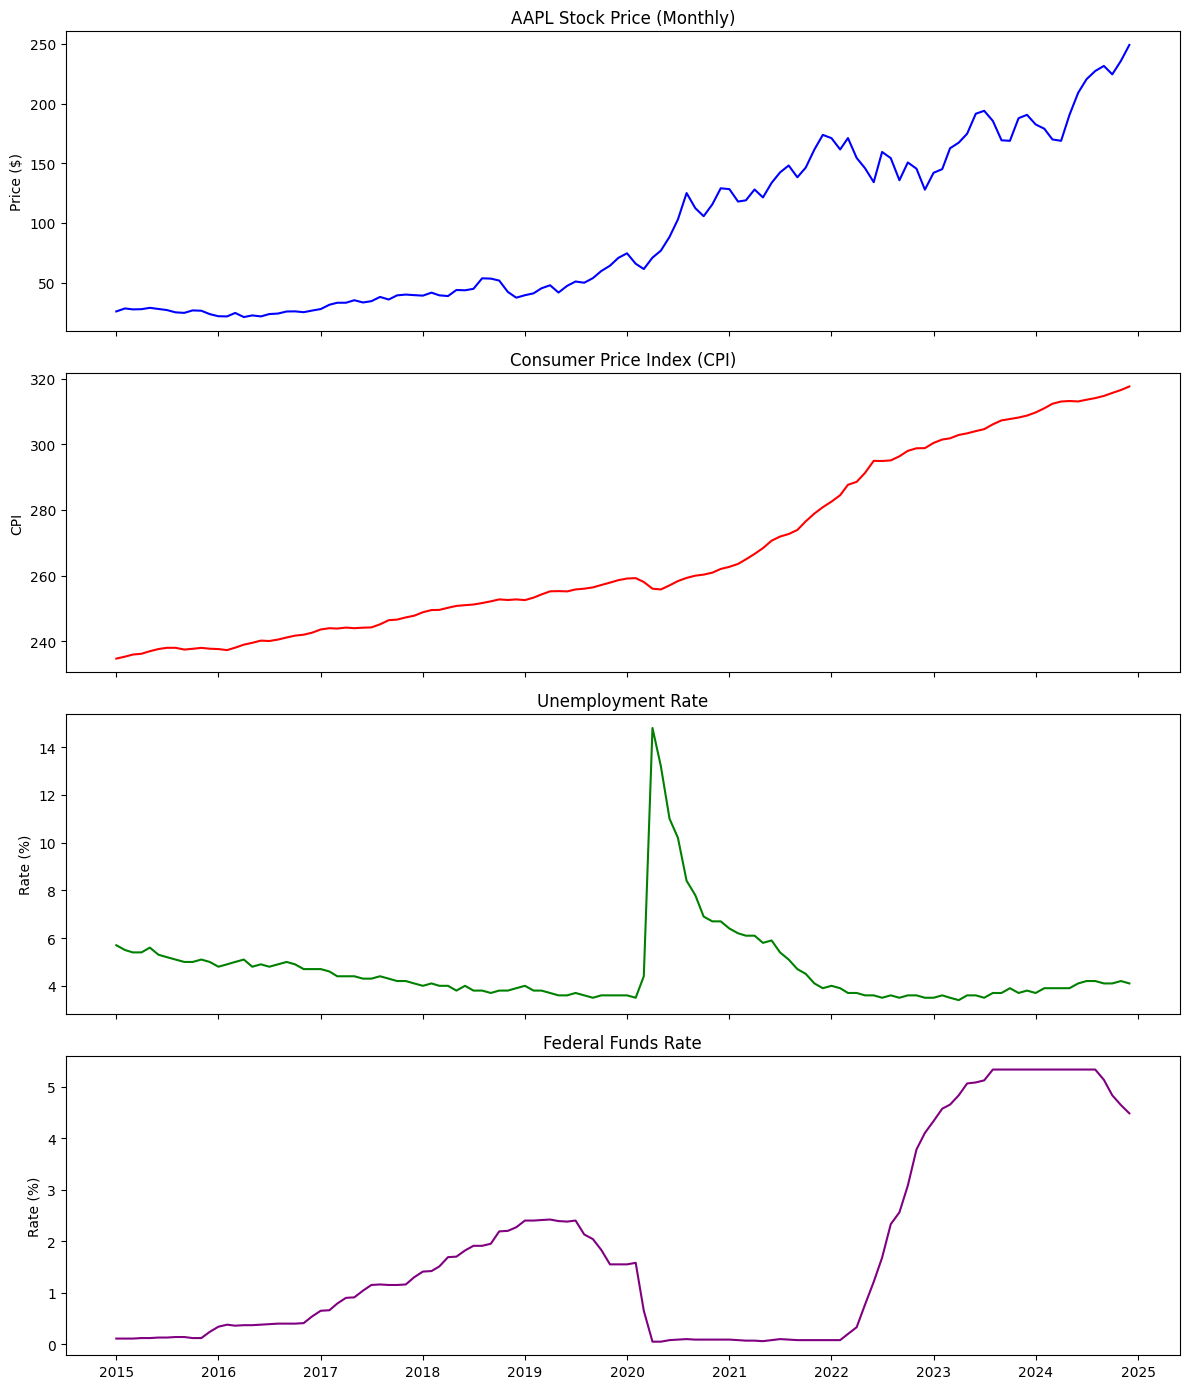

In [22]:
#Time series plots
fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

axes[0].plot(df.index.to_timestamp(), df['AAPL_Price'], color='blue')
axes[0].set_title('AAPL Stock Price (Monthly)')
axes[0].set_ylabel('Price ($)')

axes[1].plot(df.index.to_timestamp(), df['CPI'], color='red')
axes[1].set_title('Consumer Price Index (CPI)')
axes[1].set_ylabel('CPI')

axes[2].plot(df.index.to_timestamp(), df['Unemployment_Rate'], color='green')
axes[2].set_title('Unemployment Rate')
axes[2].set_ylabel('Rate (%)')

axes[3].plot(df.index.to_timestamp(), df['Fed_Funds_Rate'], color='purple')
axes[3].set_title('Federal Funds Rate')
axes[3].set_ylabel('Rate (%)')

plt.tight_layout()
plt.show()

Correlation Matrix:
                   AAPL_Price       CPI  Unemployment_Rate  Fed_Funds_Rate
AAPL_Price           1.000000  0.952721          -0.128765        0.624546
CPI                  0.952721  1.000000          -0.272768        0.790319
Unemployment_Rate   -0.128765 -0.272768           1.000000       -0.447011
Fed_Funds_Rate       0.624546  0.790319          -0.447011        1.000000



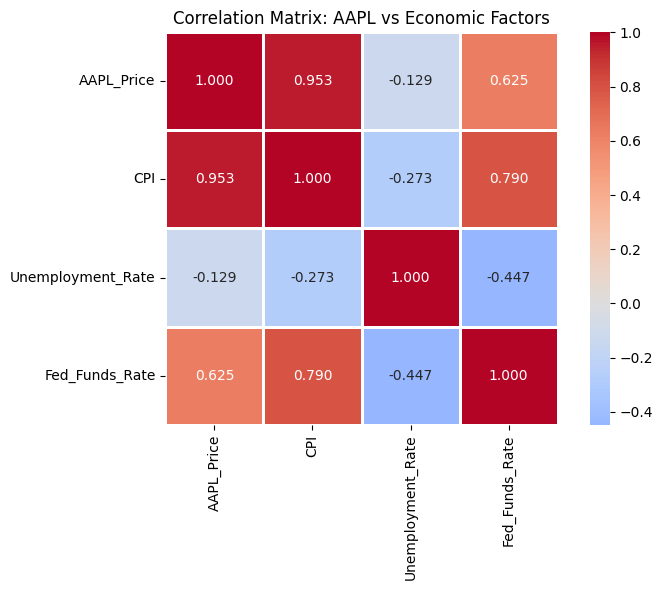

In [23]:
#Correlation analysis
correlation = df.corr()
print("Correlation Matrix:")
print(correlation)
print()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.3f',
            linewidths=1, square=True)
plt.title('Correlation Matrix: AAPL vs Economic Factors')
plt.tight_layout()
plt.show()

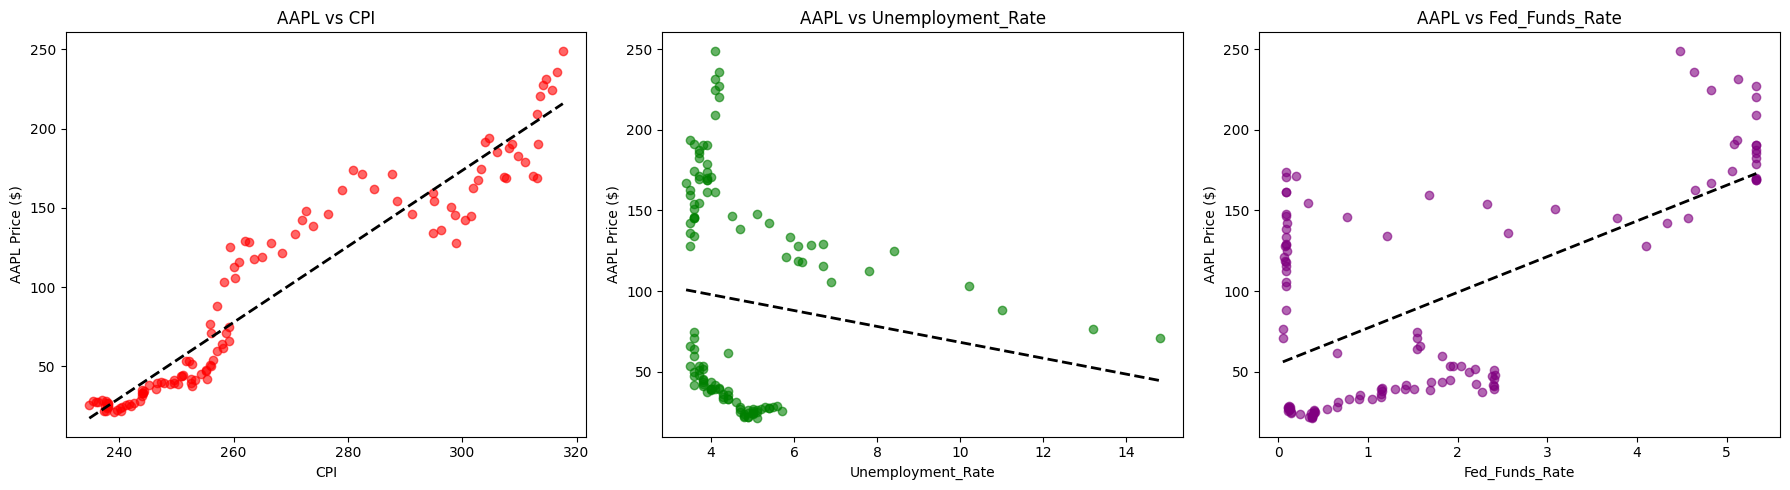

In [24]:
#Scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

factors = ['CPI', 'Unemployment_Rate', 'Fed_Funds_Rate']
colors = ['red', 'green', 'purple']

for i, (factor, color) in enumerate(zip(factors, colors)):
    axes[i].scatter(df[factor], df['AAPL_Price'], alpha=0.6, color=color)
    # Add regression line
    z = np.polyfit(df[factor], df['AAPL_Price'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[factor].min(), df[factor].max(), 100)
    axes[i].plot(x_line, p(x_line), '--', color='black', linewidth=2)
    axes[i].set_xlabel(factor)
    axes[i].set_ylabel('AAPL Price ($)')
    axes[i].set_title(f'AAPL vs {factor}')

plt.tight_layout()
plt.show()

#Findings and Insights from EDA
**1. AAPL vs CPI (Inflation) — Strong Positive Correlation**
The time series plots show that both AAPL and CPI have risen steadily over 2015–2024. This suggests a strong positive correlation. However, this does NOT
mean inflation causes stock prices to rise. Both variables share a common upward trend over time

**2. AAPL vs Unemployment Rate — Negative Correlation**
The unemployment rate generally declined from 2015 to early 2020, while AAPL rose. The COVID-19 spike in unemployment (peaking near 14.7% in April 2020) coincided with a brief AAPL dip, but AAPL recovered quickly while unemployment
took longer to normalize. This suggests a moderate negative relationship.

**3. AAPL vs Federal Funds Rate — Mixed/Weak Relationship**
The Fed Funds Rate was near zero from 2015–2016, rose gradually to ~2.4% by 2019, dropped back to near zero during COVID (2020–2022), then surged to ~5.3%
in 2023–2024. Meanwhile, AAPL rose almost continuously. This is indicative of a non-linear relationship.

**Correlation Matrix**
AAPL Price and CPI show a strong postive correlation (0.953). However, this result could be misleading as economic theory suggests that higher inflation should hurt stock prices by reducing consumer purchasing power. The strong positive correlation observed could be a case of spurious correlations which would involve detrending the data to see the actual relationsip.AAPL Price and Unemployment Rate and AAPL Price and Fed Funds Rate show a negative and moderately positive correlation respectively (-0.129 and 0.625). This confirms the patterns of the findings from the time-series analysis.

**Scatterplot analysis**
**AAPL vs CPI:** The scatter plot shows a clear upward-sloping linear pattern. This confirms the strong positive correlation of 0.953.
**AAPL vs Unemployment Rate:** The scatter plot reveals two distinct clusters rather than a smooth linear pattern. The two-cluster pattern explains the weak correlation of -0.129 — at the same low unemployment levels (~3.5–4%), AAPL
traded at vastly different prices depending on the time period. This confirms that unemployment is a poor predictor of AAPL price.

**AAPL vs Fed Funds Rate:** The scatter plot is widely dispersed,  no clean linear relationship. At near-zero rates (0–0.25%), AAPL prices range from $20 to $175, reflecting both the 2015–2016 period and the
2020–2022 period. At high rates (4.5–5.3%), AAPL prices are clustered between $125–$250. The large vertical spread at every rate level means the Fed Funds Rate explains very little of the variation in AAPL prices.

In [26]:
#Prepare data for ETS forecasting
# Use only AAPL Price as a univariate series
ts = df['AAPL_Price'].copy()
ts.index = ts.index.to_timestamp()
ts = ts.asfreq('MS')

# Train/Test split: last 12 months as test set
train = ts[:-12]
test = ts[-12:]

#define accuracy metrics

def calculate_metrics(actual, predicted, model_name):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    # Additional metric 1: MASE (Mean Absolute Scaled Error)
    naive_errors = np.abs(np.diff(train.values))
    mase = mae / np.mean(naive_errors)
    # Additional metric 2: MdAPE (Median Absolute Percentage Error)
    mdape = np.median(np.abs((actual - predicted) / actual)) * 100

    return {
        'Model': model_name,
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4),
        'MAPE (%)': round(mape, 4),
        'MASE': round(mase, 4),
        'MdAPE (%)': round(mdape, 4)
    }

In [33]:
#  Fit multiple ETS models
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_squared_error, mean_absolute_error
results_list = []
forecasts = {}

ets_configs = [
    ('ETS(A,N,N)',  {'error': 'add', 'trend': None, 'seasonal': None, 'damped_trend': False}),
    ('ETS(A,A,N)',  {'error': 'add', 'trend': 'add', 'seasonal': None, 'damped_trend': False}),
    ('ETS(A,Ad,N)', {'error': 'add', 'trend': 'add', 'seasonal': None, 'damped_trend': True}),
    ('ETS(M,N,N)',  {'error': 'mul', 'trend': None, 'seasonal': None, 'damped_trend': False}),
    ('ETS(M,M,N)',  {'error': 'mul', 'trend': 'mul', 'seasonal': None, 'damped_trend': False}),
    ('ETS(M,Md,N)', {'error': 'mul', 'trend': 'mul', 'seasonal': None, 'damped_trend': True}),
]

for name, config in ets_configs:
    try:
        model = ETSModel(train,
                         error=config['error'],
                         trend=config['trend'],
                         seasonal=config['seasonal'],
                         damped_trend=config['damped_trend'])
        fit = model.fit(disp=False, maxiter=1000)
        forecast = fit.forecast(steps=12)
        metrics = calculate_metrics(test.values, forecast.values, name)
        results_list.append(metrics)
        forecasts[name] = forecast
        print(f" {name} fitted successfully | AIC: {fit.aic:.2f}")
    except Exception as e:
        print(f" {name} failed: {e}")

# Results table
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values('RMSE')
print("\n" + "="*80)
print("MODEL COMPARISON (sorted by RMSE)")
print("="*80)
results_df

 ETS(A,N,N) fitted successfully | AIC: 762.89
 ETS(A,A,N) fitted successfully | AIC: 762.91
 ETS(A,Ad,N) fitted successfully | AIC: 767.37
 ETS(M,N,N) fitted successfully | AIC: 669.48
 ETS(M,M,N) fitted successfully | AIC: 665.82
 ETS(M,Md,N) fitted successfully | AIC: 670.83

MODEL COMPARISON (sorted by RMSE)


,Model,RMSE,MAE,MAPE (%),MASE,MdAPE (%)
4,"ETS(M,M,N)",18.2510,13.2513,7.2329,2.2900,4.8513
5,"ETS(M,Md,N)",20.1420,18.4019,9.0526,3.1801,8.6637
1,"ETS(A,A,N)",22.9257,20.9811,10.0617,3.6259,9.6876
2,"ETS(A,Ad,N)",26.6679,23.8342,11.1979,4.1189,12.2584
3,"ETS(M,N,N)",31.5807,27.1365,12.4942,4.6896,13.2116
0,"ETS(A,N,N)",31.5807,27.1365,12.4942,4.6896,13.2116


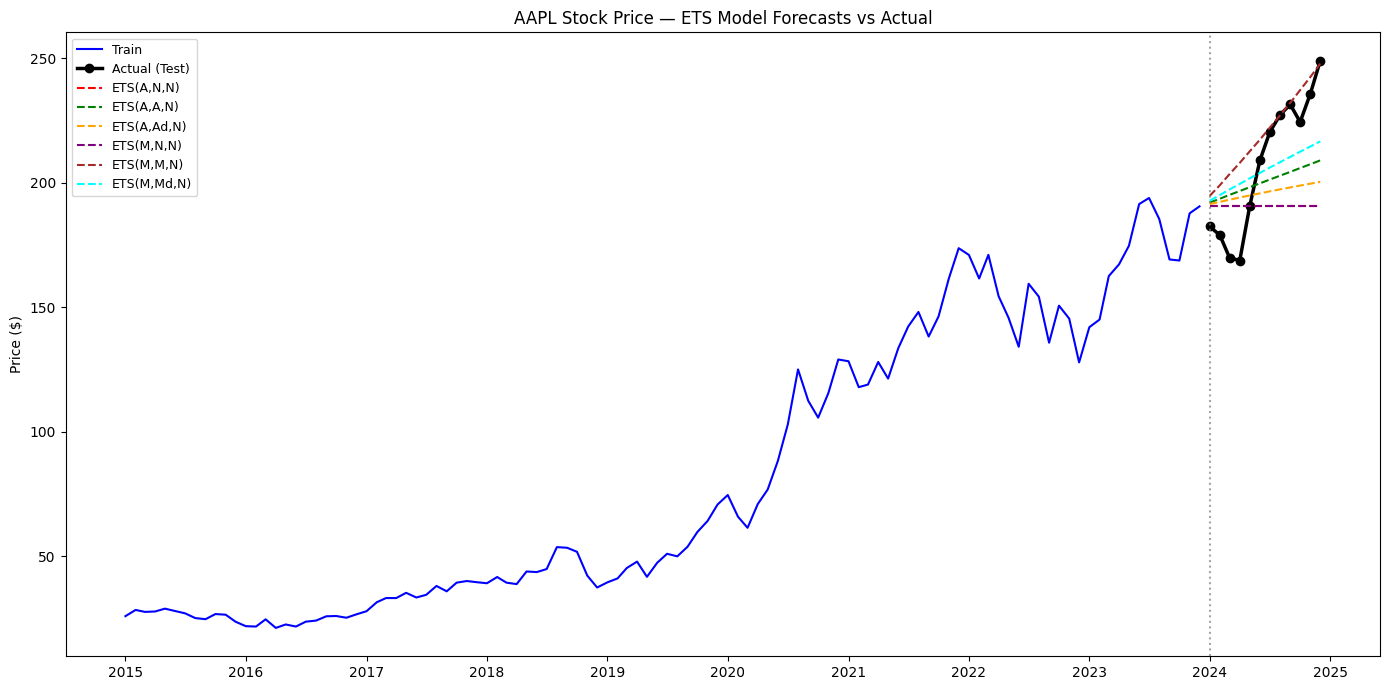

In [34]:
#Visualize forecasts
plt.figure(figsize=(14, 7))
plt.plot(train.index, train, label='Train', color='blue', linewidth=1.5)
plt.plot(test.index, test, label='Actual (Test)', color='black', linewidth=2.5, marker='o')

colors = ['red', 'green', 'orange', 'purple', 'brown', 'cyan']
for i, (name, forecast) in enumerate(forecasts.items()):
    plt.plot(test.index, forecast, label=name, linestyle='--', color=colors[i % len(colors)], linewidth=1.5)

plt.axvline(x=test.index[0], color='gray', linestyle=':', alpha=0.7)
plt.title('AAPL Stock Price — ETS Model Forecasts vs Actual')
plt.ylabel('Price ($)')
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

##ETS Model Evaluation & Interpretation

### Model Results Summary

Six ETS models were fitted to the AAPL training data and evaluated on a 12-month
test set (holdout). The models were assessed using five accuracy metrics: RMSE,
MAE, MAPE, MASE, and MdAPE.

**MASE (Mean Absolute Scaled Error):** MASE was chosen because it scales the
forecast error relative to the naive forecast (random walk), making it scale-independent and interpretable across different series. A MASE below 1.0 means the model beats the naive method. All models have MASE above 1.0,
indicating that even the best ETS model struggles to consistently outperform a simple naive forecast.

**MdAPE (Median Absolute Percentage Error):** MdAPE was chosen because it is more robust to outliers than MAPE.

### Best Model: ETS(M,M,N) — Multiplicative Error, Multiplicative Trend, No Seasonality

The ETS(M,M,N) model outperforms all other models across every metric. It achieves the lowest RMSE (18.25), MAE (13.25), MAPE (7.23%), MASE (2.29), and
MdAPE (4.85%). This model assumes that both the error and the trend component scale, which makes intuitive sense
for stock prices. The multiplicative trend shows AAPL's exponential growth pattern better than a simple additive (linear) trend.

The two worst-performing models — ETS(A,N,N) and ETS(M,N,N) — have no trend component. These models produce flat forecasts at the last estimated level, missing AAPL's upward trajectory during the test period. This explains their high RMSE of 31.58 and MAPE of 12.49%. Including a trend component
(additive or multiplicative) substantially improves accuracy.

NOTE: Claude was used for debugging and generating some of the code related to the plots.